## Task

In [172]:
import pandas as pd
from IPython.display import display

# Define the data as a list of lists (excluding 'Individual Responsible' column)
data = [
    ["Bidirectional LSTM model using embedding layer", "Config of the model trained", "Train Time = 1739.66 seconds"],
    ["Training Data Check", "Confusion Matrix Built?", "Yes"],
    ["", "F1 Score for Positive = ?", "0.92"],
    ["", "F1 Score for Negative = ?", "0.96"],
    ["", "AUC plotted?", "Yes"],
    ["", "AUC = ", "AUC for Class 0 on Training Data: 0.99, AUC for Class 1 on Training Data: 0.98, AUC for Class 2 on Training Data: 0.98"],
    ["", "Accuracy computed?", "0.93"],
    ["Cross Validation", "", ""],
    ["Interpretability", "local(LIME)", "Words highly associated with the negative setiment"],
    ["Testing Data Check", "Confusion Matrix Built?", "Yes"],
    ["", "F1 Score for Positive = ?", "0.82"],
    ["", "F1 Score for Negative = ?", "0.90"],
    ["", "AUC plotted?", "Yes"],
    ["", "AUC = ", "AUC for Class 0 on Test Data: 0.96, AUC for Class 1 on Test Data: 0.95, AUC for Class 2 on Test Data: 0.92"],
    ["", "Accuracy computed?", "0.85"],    
    ["Data Preprocessing and Feature Engg", "Regex Used?", "yes"],
    ["", "Emoji Handling Done?", "yes"],
    ["", "Slang Handling Done?", "yes"],
    ["", "Abbreviations Handled?", "yes"],
    ["", "Negation Handled?", "yes"],
    ["", "Class Separability Checked?", "yes"],
    ["", "Train and Test Handled Correctly?", "yes"],
]

# Create a DataFrame
Task = pd.DataFrame(data, columns=["Task", "Status", "Results"])

# Display the table in Jupyter Notebook
display(Task)


,Task,Status,Results
0,Bidirectional LSTM model using embedding layer,Config of the model trained,Train Time = 1739.66 seconds
1,Training Data Check,Confusion Matrix Built?,Yes
2,,F1 Score for Positive = ?,0.92
3,,F1 Score for Negative = ?,0.96
4,,AUC plotted?,Yes
5,,AUC =,"AUC for Class 0 on Training Data: 0.99, AUC fo..."
6,,Accuracy computed?,0.93
7,Cross Validation,,
8,Interpretability,local(LIME),Words highly associated with the negative seti...
9,Testing Data Check,Confusion Matrix Built?,Yes


## Imports

In [93]:
import pandas as pd
import numpy as np
import re
import emoji
import contractions
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, SpatialDropout1D
from imblearn.over_sampling import SMOTE
import time
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\JISNA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\JISNA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\JISNA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\JISNA\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Load Dataset

In [94]:
df = pd.read_csv(r"C:\Users\JISNA\Desktop\sem 3\NLP\Sentiment_Data.csv", encoding='ISO-8859-1')
df = df.sample(30000, random_state=42)  # Take a sample of 30,000
df.head(5)

,Tweet,Sentiment
420483,stupid fucking freedom convoy is going past th...,Strong_Neg
320604,Freedom Convoy coming to a country near you! S...,Strong_Pos
68154,@CTVNews The main thing is that the Freedom/An...,Neutral
100473,Residents who Chauvin says previously agreed t...,Mild_Pos
303998,MSNBC guest says Freedom Convoy truckers throw...,Mild_Pos


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 420483 to 161649
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet      30000 non-null  object
 1   Sentiment  30000 non-null  object
dtypes: object(2)
memory usage: 703.1+ KB


### Null Values check

In [96]:
null_values = df.isnull().sum()
print("Null values in each column:")
print(null_values)

Null values in each column:
Tweet        0
Sentiment    0
dtype: int64


In [97]:
df.columns

Index(['Tweet', 'Sentiment'], dtype='object')

In [98]:
unique_sentiments = df['Sentiment'].unique()
print(unique_sentiments)

['Strong_Neg' 'Strong_Pos' 'Neutral' 'Mild_Pos' 'Mild_Neg']


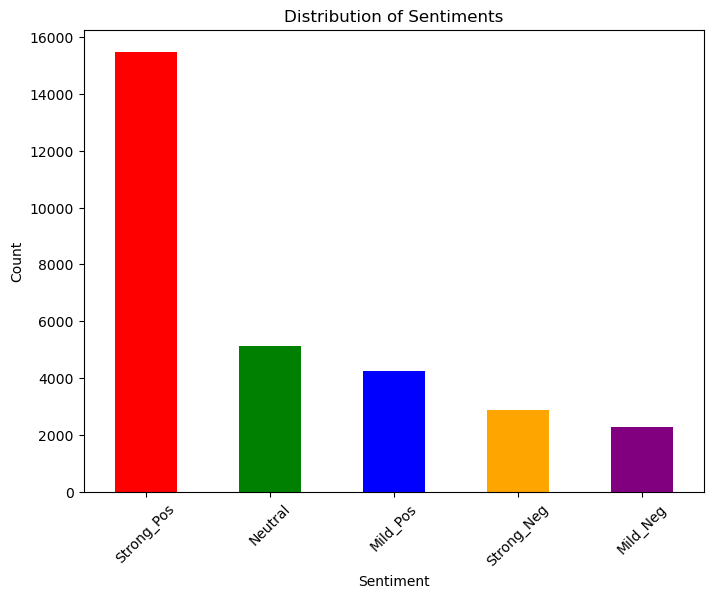

In [99]:
# Count the occurrences of each sentiment
sentiment_counts = df['Sentiment'].value_counts()

# Plot the distribution
plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['red', 'green', 'blue', 'orange', 'purple'])
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

In [100]:
print(sentiment_counts)

Sentiment
Strong_Pos    15480
Neutral        5124
Mild_Pos       4249
Strong_Neg     2861
Mild_Neg       2286
Name: count, dtype: int64


## Data Preprocessing

### Cleaning Text

In [101]:
# Regex-based Cleaning Functions
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+', '', text)  # Remove mentions
    text = re.sub(r'#[A-Za-z0-9]+', '', text)  # Remove hashtags
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # Remove special characters
    return text

df['Tweet'] = df['Tweet'].apply(clean_text)

### Emojis Handiling

In [102]:
def handle_emojis(text):
    return emoji.demojize(text)
    
df['Tweet'] = df['Tweet'].apply(handle_emojis)

### Contractions

In [103]:
def expand_contractions(text):
    return contractions.fix(text)
    
df['Tweet'] = df['Tweet'].apply(expand_contractions)

### Slang and Abbreviation Handling

In [104]:
slang_dict = {"u": "you", "ur": "your", "idk": "i don't know", "btw": "by the way", "smh": "shaking my head"}

def replace_slang(text):
    words = text.split()
    return ' '.join([slang_dict[word] if word in slang_dict else word for word in words])

df['Tweet'] = df['Tweet'].apply(replace_slang)

### Tokenization and Stopword Removal

In [105]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['Tweet'] = df['Tweet'].apply(preprocess_text)

In [106]:
# combine data
df['Sentiment'] = df['Sentiment'].replace({
    'Strong_Pos': 'Positive',
    'Mild_Pos': 'Positive',
    'Strong_Neg': 'Negative',
    'Mild_Neg': 'Negative',
    'Neutral': 'Neutral'
})
df.head()

,Tweet,Sentiment
420483,stupid fucking freedom convoy going past store...,Negative
320604,freedom convoy coming country near starting ma...,Positive
68154,main thing freedomantimandate convoy cost trud...,Neutral
100473,resident chauvin say previously agreed leave l...,Positive
303998,msnbc guest say freedom convoy trucker throwin...,Positive


In [107]:
print(df['Sentiment'].unique())

['Negative' 'Positive' 'Neutral']


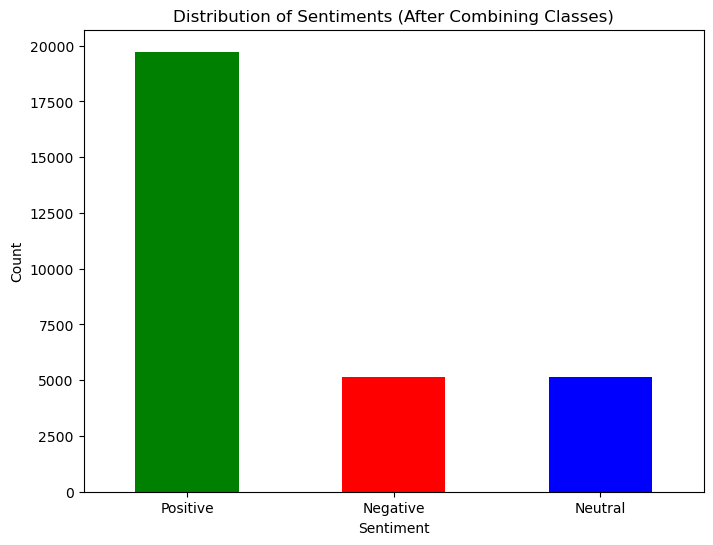

In [108]:
# Count the occurrences of each sentiment
sentiment_counts = df['Sentiment'].value_counts()

# Plot the distribution
plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Distribution of Sentiments (After Combining Classes)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.show()

### Label Encoding

In [109]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['Sentiment'] = label_encoder.fit_transform(df['Sentiment'])

In [110]:
print(sentiment_counts)

Sentiment
Positive    19729
Negative     5147
Neutral      5124
Name: count, dtype: int64


In [111]:
print(df['Sentiment'].value_counts())

Sentiment
2    19729
0     5147
1     5124
Name: count, dtype: int64


## Class-Balancing 

### Random Over sampling

In [112]:
# Handling Class Imbalance (Oversampling)

from sklearn.utils import resample

positive = df[df['Sentiment'] == 2]
negative = df[df['Sentiment'] == 0]
neutral = df[df['Sentiment'] == 1]

negative_upsampled = resample(negative, replace=True, n_samples=19729, random_state=42)
neutral_upsampled = resample(neutral, replace=True, n_samples=19729, random_state=42)

balanced_df = pd.concat([positive, negative_upsampled, neutral_upsampled])


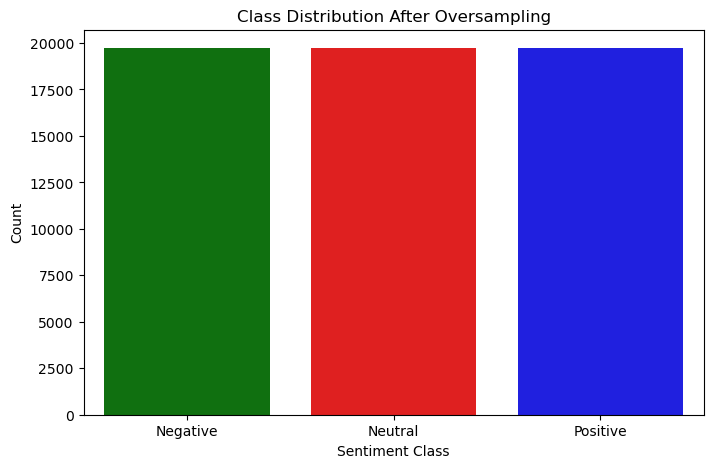

In [113]:
# Count the new class distribution
class_counts_after = balanced_df['Sentiment'].value_counts().reset_index()
class_counts_after.columns = ['Sentiment', 'Count']

# Define custom colors
custom_colors = {0: 'red', 1: 'blue', 2: 'green'}

# Plot after oversampling
plt.figure(figsize=(8, 5))
sns.barplot(
    data=class_counts_after, 
    x="Sentiment", 
    y="Count", 
    hue="Sentiment", 
    palette=[custom_colors[i] for i in class_counts_after['Sentiment']], 
    legend=False
)

plt.xlabel("Sentiment Class")
plt.ylabel("Count")
plt.title("Class Distribution After Oversampling")
plt.xticks(ticks=[0, 1, 2], labels=["Negative", "Neutral", "Positive"])
plt.show()

### Tokenization & Padding

In [114]:
from tensorflow.keras.utils import to_categorical

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(balanced_df['Tweet'])  
sequences = tokenizer.texts_to_sequences(balanced_df['Tweet'])  
X = pad_sequences(sequences, maxlen=100, padding='post')
y = to_categorical(balanced_df['Sentiment'])

## Splitting

In [115]:
from sklearn.model_selection import train_test_split

# Split the data into training+validation and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [116]:
# Split the training+validation set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

# Check the shapes of the datasets
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_val:", y_val.shape)
print("Shape of X_test:", X_test.shape)

Shape of X_train: (37879, 100)
Shape of y_train: (37879, 3)
Shape of X_val: (9470, 100)
Shape of y_val: (9470, 3)
Shape of X_test: (11838, 100)


## BiLSTM Model

In [117]:
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense

# Model definition
def build_model():
    model = Sequential([
        Embedding(input_dim=10000, output_dim=128), 
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.5),
        Bidirectional(LSTM(32)),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Build the model
model = build_model()

# Explicitly build the model by passing an input shape
model.build(input_shape=(None, 100)) 

In [118]:
# Print the model summary
model.summary()
model = build_model()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)              │ (None, 100, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_8 (Bidirectional)      │ (None, 100, 128)            │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 100, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_9 (Bidirectional)      │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,424,387 (5.43 MB)

 Trainable params: 1,424,387 (5.43 MB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [119]:
# Record the start time
start_time = time.time()

# Train the model with validation data
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val), 
    epochs=10,
    batch_size=64,
    verbose=1
)

# Record the end time
end_time = time.time()

# Calculate the training time
training_time = end_time - start_time
print(f"Training time: {training_time:.2f} seconds")

Epoch 1/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 124s 193ms/step - accuracy: 0.5959 - loss: 0.8663 - val_accuracy: 0.7899 - val_loss: 0.5360
Epoch 2/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 135s 182ms/step - accuracy: 0.8403 - loss: 0.4350 - val_accuracy: 0.8377 - val_loss: 0.4430
Epoch 3/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 140s 178ms/step - accuracy: 0.9046 - loss: 0.2802 - val_accuracy: 0.8663 - val_loss: 0.4096
Epoch 4/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 142s 179ms/step - accuracy: 0.9349 - loss: 0.1989 - val_accuracy: 0.8778 - val_loss: 0.3817
Epoch 5/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 113s 191ms/step - accuracy: 0.9484 - loss: 0.1551 - val_accuracy: 0.8907 - val_loss: 0.4065
Epoch 6/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 136s 181ms/step - accuracy: 0.9598 - loss: 0.1207 - val_accuracy: 0.8938 - val_loss: 0.4381
Epoch 7/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 141s 180ms/step - accuracy: 0.9651 - loss: 0.1016 - val_accuracy: 0.8817 - val_loss: 0.4767
Epoch 8/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 141s 178ms/step - accuracy: 0.9716 -

## Model Evaluation

### Confusion Matrix

1184/1184 ━━━━━━━━━━━━━━━━━━━━ 36s 30ms/step
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step


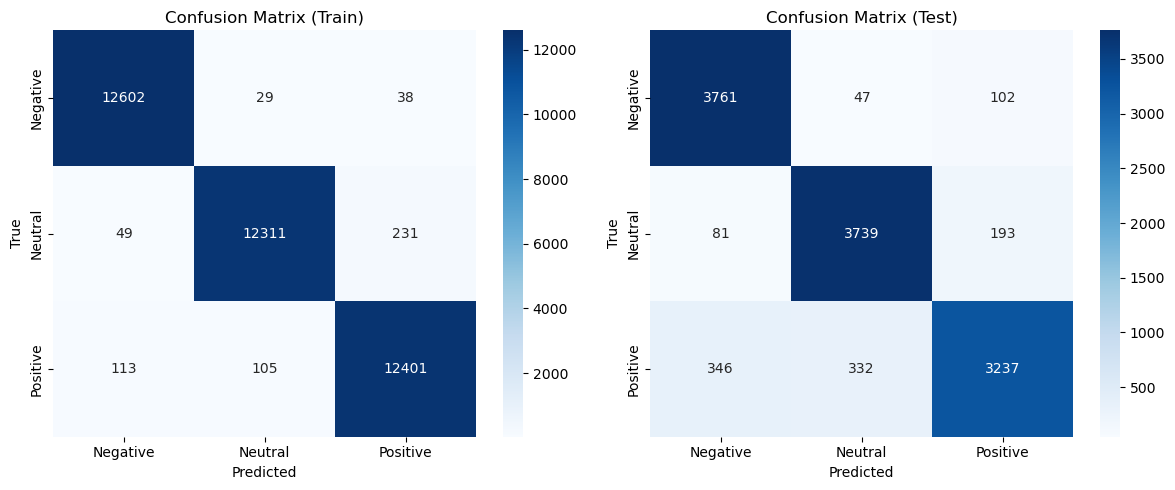

In [120]:
from sklearn.metrics import confusion_matrix

# Get predictions for train and test sets
y_pred_train = np.argmax(model.predict(X_train), axis=1)
y_pred_test = np.argmax(model.predict(X_test), axis=1)

# True labels
y_true_train = np.argmax(y_train, axis=1)
y_true_test = np.argmax(y_test, axis=1)

# Compute confusion matrices
cm_train = confusion_matrix(y_true_train, y_pred_train)
cm_test = confusion_matrix(y_true_test, y_pred_test)

# Plot confusion matrices
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix (Train)')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1, 2, 2)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix (Test)')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.tight_layout()
plt.show()

### ROC and AUC

1184/1184 ━━━━━━━━━━━━━━━━━━━━ 34s 29ms/step
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step


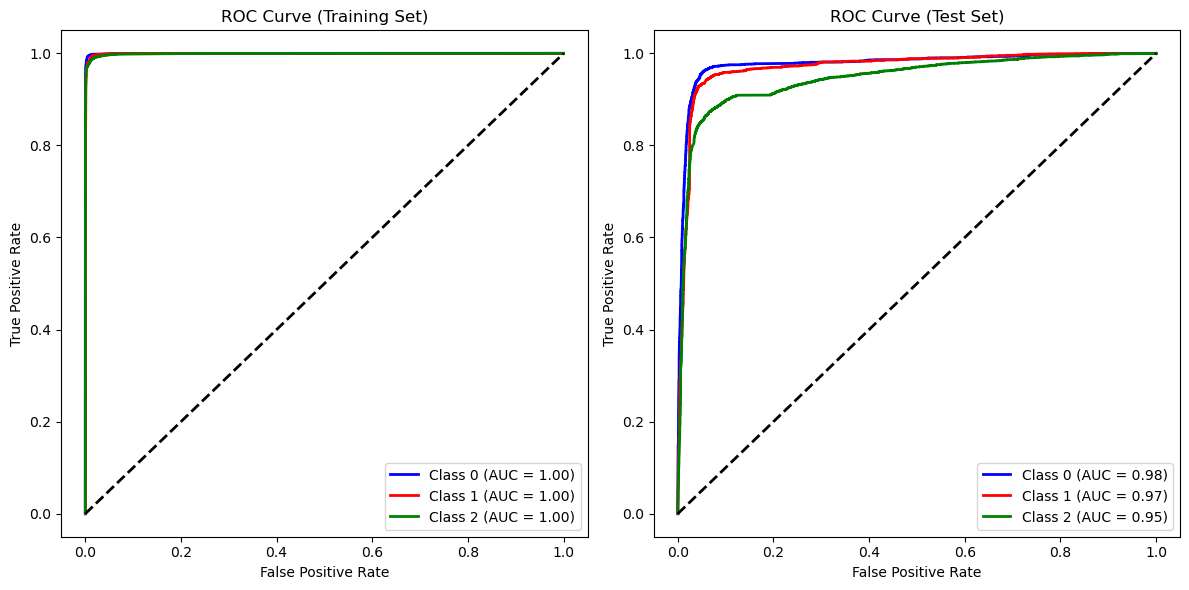

Training Set AUC:
Class 0: 1.00
Class 1: 1.00
Class 2: 1.00

Test Set AUC:
Class 0: 0.98
Class 1: 0.97
Class 2: 0.95


In [121]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the true labels for multi-class ROC
y_train_bin = label_binarize(y_train, classes=[0, 1, 2])
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_train_bin.shape[1]

# Predict probabilities for each class (train and test)
y_train_pred_proba = model.predict(X_train)
y_test_pred_proba = model.predict(X_test)

# Compute ROC curve and AUC for each class (train and test)
def compute_roc_auc(y_true, y_pred_proba, n_classes):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    return fpr, tpr, roc_auc

fpr_train, tpr_train, roc_auc_train = compute_roc_auc(y_train_bin, y_train_pred_proba, n_classes)
fpr_test, tpr_test, roc_auc_test = compute_roc_auc(y_test_bin, y_test_pred_proba, n_classes)

# Plot ROC curves for both train and test
plt.figure(figsize=(12, 6))

# ROC curves for training set
plt.subplot(1, 2, 1)
colors = ['blue', 'red', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_train[i], tpr_train[i], color=color, lw=2, label=f'Class {i} (AUC = {roc_auc_train[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Training Set)')
plt.legend(loc='lower right')

# ROC curves for test set
plt.subplot(1, 2, 2)
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_test[i], tpr_test[i], color=color, lw=2, label=f'Class {i} (AUC = {roc_auc_test[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Print AUC for each class (train and test)
print("Training Set AUC:")
for i in range(n_classes):
    print(f"Class {i}: {roc_auc_train[i]:.2f}")

print("\nTest Set AUC:")
for i in range(n_classes):
    print(f"Class {i}: {roc_auc_test[i]:.2f}")

### Accuracy

In [122]:
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=1)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"Train Loss: {train_loss}")
print(f"Test Loss: {test_loss}")
print(f"Train Accuracy: {train_accuracy}")
print(f"Test Accuracy: {test_accuracy}")

1184/1184 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - accuracy: 0.9843 - loss: 0.0423
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.9018 - loss: 0.5429
Train Loss: 0.04114117473363876
Test Loss: 0.5119820833206177
Train Accuracy: 0.985084056854248
Test Accuracy: 0.9069944024085999


### Train Validation

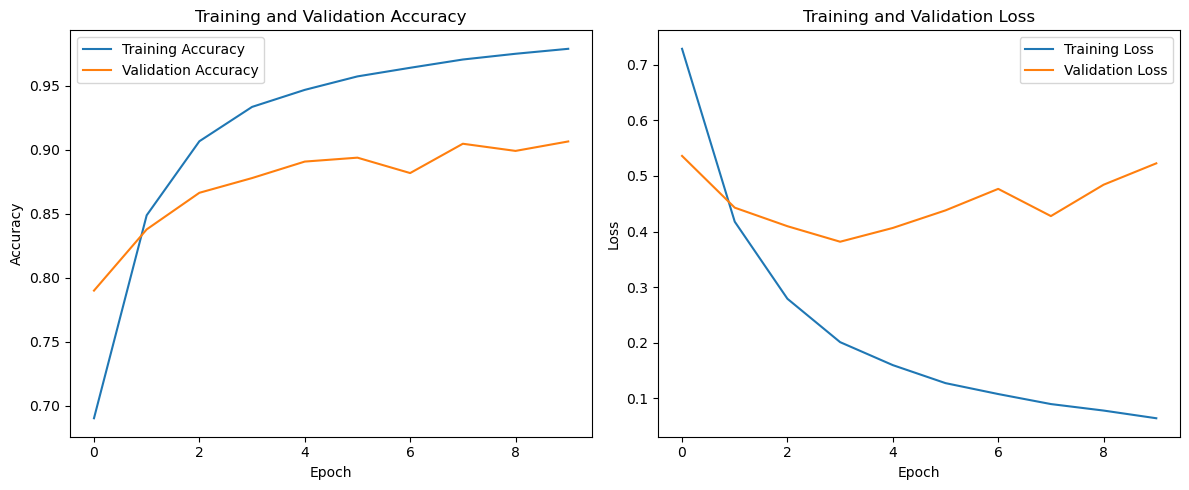

In [123]:
# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [124]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict labels for the test set
predicted_classes = np.argmax(model.predict(X_test), axis=1)

# Convert one-hot encoded y_test to class labels
y_test_classes = np.argmax(y_test, axis=1)

# Generate the classification report
print("Classification Report:")
print(classification_report(y_test_classes, predicted_classes, target_names=['Negative', 'Neutral', 'Positive']))

# Generate the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test_classes, predicted_classes))

370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step
Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.96      0.93      3910
     Neutral       0.91      0.93      0.92      4013
    Positive       0.92      0.83      0.87      3915

    accuracy                           0.91     11838
   macro avg       0.91      0.91      0.91     11838
weighted avg       0.91      0.91      0.91     11838

Confusion Matrix:
[[3761   47  102]
 [  81 3739  193]
 [ 346  332 3237]]


Analysis:
This showing there is a slight overfitting.

## Regularization for overfitting

### L2 Regularization

In [125]:
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense

# Model definition with L2 regularization
def build_model():
    model = Sequential([
        Embedding(input_dim=10000, output_dim=128), 
        Bidirectional(LSTM(64, return_sequences=True, 
                            kernel_regularizer=regularizers.l2(0.01))),  # Correct use of regularizers.l2
        Dropout(0.5),
        Bidirectional(LSTM(32, kernel_regularizer=regularizers.l2(0.01))),  # Correct use of regularizers.l2
        Dense(64, activation='relu', 
              kernel_regularizer=regularizers.l2(0.01)),  # Correct use of regularizers.l2
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Build the model
model = build_model()

# Explicitly build the model by passing an input shape
model.build(input_shape=(None, 100)) 

In [126]:
# Print the model summary
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)              │ (None, 100, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_12 (Bidirectional)     │ (None, 100, 128)            │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 100, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_13 (Bidirectional)     │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,424,387 (5.43 MB)

 Trainable params: 1,424,387 (5.43 MB)

 Non-trainable params: 0 (0.00 B)

In [127]:
# Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Record the start time
start_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val), 
    epochs=15,  
    batch_size=64,
    verbose=1,
    callbacks=[early_stopping]  
)
# Record the end time
end_time = time.time()

# Calculate the training time
training_time = end_time - start_time
print(f"Training time: {training_time:.2f} seconds")


Epoch 1/15
592/592 ━━━━━━━━━━━━━━━━━━━━ 128s 200ms/step - accuracy: 0.4647 - loss: 2.5905 - val_accuracy: 0.6710 - val_loss: 0.8396
Epoch 2/15
592/592 ━━━━━━━━━━━━━━━━━━━━ 135s 189ms/step - accuracy: 0.6861 - loss: 0.8308 - val_accuracy: 0.7356 - val_loss: 0.7278
Epoch 3/15
592/592 ━━━━━━━━━━━━━━━━━━━━ 142s 188ms/step - accuracy: 0.7940 - loss: 0.6203 - val_accuracy: 0.7901 - val_loss: 0.5980
Epoch 4/15
592/592 ━━━━━━━━━━━━━━━━━━━━ 123s 208ms/step - accuracy: 0.8454 - loss: 0.4795 - val_accuracy: 0.8121 - val_loss: 0.5588
Epoch 5/15
592/592 ━━━━━━━━━━━━━━━━━━━━ 130s 187ms/step - accuracy: 0.8697 - loss: 0.4208 - val_accuracy: 0.8124 - val_loss: 0.5628
Epoch 6/15
592/592 ━━━━━━━━━━━━━━━━━━━━ 142s 187ms/step - accuracy: 0.8852 - loss: 0.3759 - val_accuracy: 0.8134 - val_loss: 0.5631
Epoch 7/15
592/592 ━━━━━━━━━━━━━━━━━━━━ 118s 200ms/step - accuracy: 0.8950 - loss: 0.3589 - val_accuracy: 0.8352 - val_loss: 0.5169
Epoch 8/15
592/592 ━━━━━━━━━━━━━━━━━━━━ 116s 195ms/step - accuracy: 0.9059 -

## Model Evaluation

### Confusion Matrix

1184/1184 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step


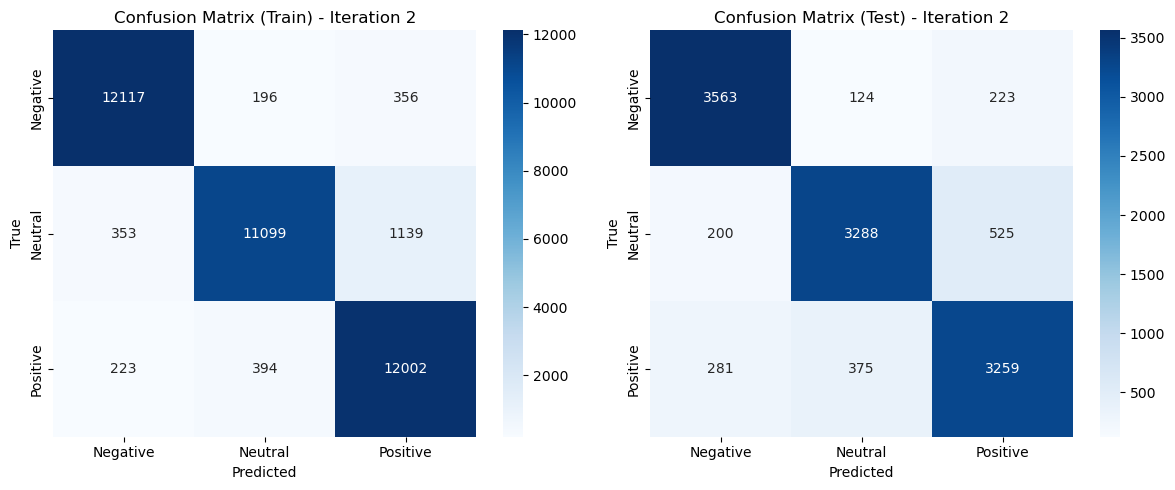

In [128]:
# Get predictions for train and test sets after second iteration
y_pred_train_2 = np.argmax(model.predict(X_train), axis=1)
y_pred_test_2 = np.argmax(model.predict(X_test), axis=1)

# True labels for train and test sets
y_true_train_2 = np.argmax(y_train, axis=1)
y_true_test_2 = np.argmax(y_test, axis=1)

# Compute confusion matrices for train and test sets
cm_train_2 = confusion_matrix(y_true_train_2, y_pred_train_2)
cm_test_2 = confusion_matrix(y_true_test_2, y_pred_test_2)

# Plot confusion matrices
plt.figure(figsize=(12, 5))

# Train Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(cm_train_2, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix (Train) - Iteration 2')
plt.xlabel('Predicted')
plt.ylabel('True')

# Test Confusion Matrix
plt.subplot(1, 2, 2)
sns.heatmap(cm_test_2, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix (Test) - Iteration 2')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.tight_layout()
plt.show()


### ROC and AUC

1184/1184 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step
370/370 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step


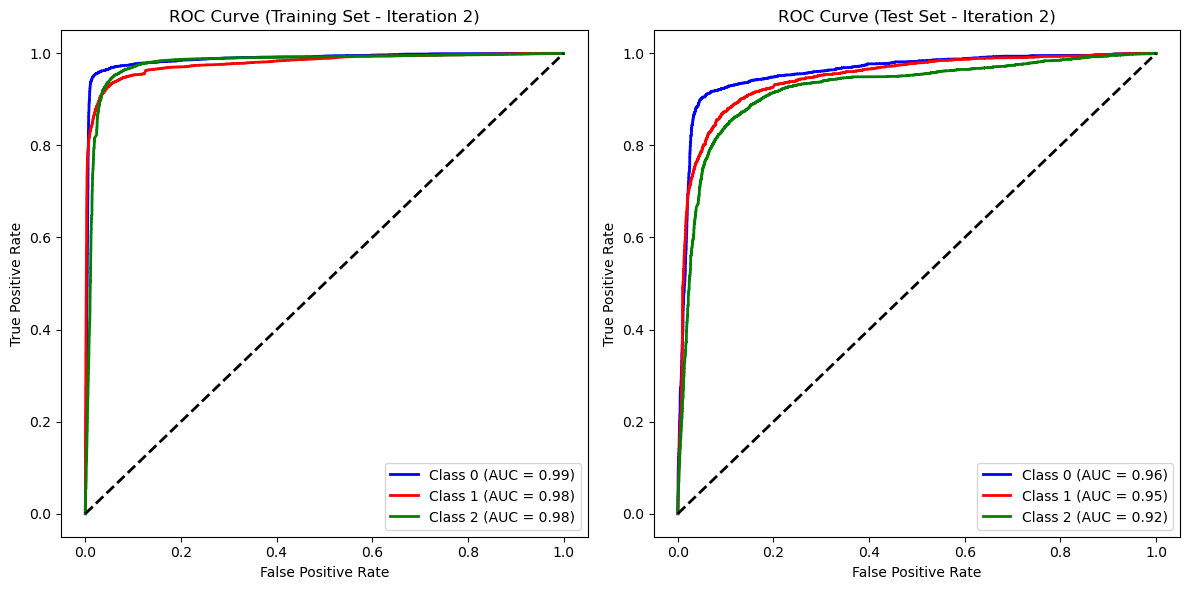

Training Set AUC (Iteration 2):
Class 0: 0.99
Class 1: 0.98
Class 2: 0.98

Test Set AUC (Iteration 2):
Class 0: 0.96
Class 1: 0.95
Class 2: 0.92


In [129]:
# Binarize the true labels for multi-class ROC (for second iteration)
y_train_bin_2 = label_binarize(y_train, classes=[0, 1, 2])  
y_test_bin_2 = label_binarize(y_test, classes=[0, 1, 2])    

n_classes = y_train_bin_2.shape[1]  

# Predict probabilities for each class (train and test) using the trained model
y_train_pred_proba_2 = model.predict(X_train)  
y_test_pred_proba_2 = model.predict(X_test)    

# Compute ROC curve and AUC for each class (train and test)
def compute_roc_auc(y_true, y_pred_proba, n_classes):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    return fpr, tpr, roc_auc

# Compute ROC and AUC for training and test sets
fpr_train_2, tpr_train_2, roc_auc_train_2 = compute_roc_auc(y_train_bin_2, y_train_pred_proba_2, n_classes)
fpr_test_2, tpr_test_2, roc_auc_test_2 = compute_roc_auc(y_test_bin_2, y_test_pred_proba_2, n_classes)

# Plot ROC curves for both train and test
plt.figure(figsize=(12, 6))

# ROC curves for training set
plt.subplot(1, 2, 1)
colors = ['blue', 'red', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_train_2[i], tpr_train_2[i], color=color, lw=2, label=f'Class {i} (AUC = {roc_auc_train_2[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Training Set - Iteration 2)')
plt.legend(loc='lower right')

# ROC curves for test set
plt.subplot(1, 2, 2)
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_test_2[i], tpr_test_2[i], color=color, lw=2, label=f'Class {i} (AUC = {roc_auc_test_2[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set - Iteration 2)')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Print AUC for each class (train and test)
print("Training Set AUC (Iteration 2):")
for i in range(n_classes):
    print(f"Class {i}: {roc_auc_train_2[i]:.2f}")

print("\nTest Set AUC (Iteration 2):")
for i in range(n_classes):
    print(f"Class {i}: {roc_auc_test_2[i]:.2f}")


### Accuracy

In [130]:
# Evaluate the model on the training and testing data (second iteration)
train_loss_2, train_accuracy_2 = model.evaluate(X_train, y_train, verbose=1)
test_loss_2, test_accuracy_2 = model.evaluate(X_test, y_test, verbose=1)

# Print the loss and accuracy for the training and testing sets
print(f"Train Loss (Iteration 2): {train_loss_2}")
print(f"Test Loss (Iteration 2): {test_loss_2}")
print(f"Train Accuracy (Iteration 2): {train_accuracy_2}")
print(f"Test Accuracy (Iteration 2): {test_accuracy_2}")

1184/1184 ━━━━━━━━━━━━━━━━━━━━ 37s 32ms/step - accuracy: 0.9297 - loss: 0.2607
370/370 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.8523 - loss: 0.5143
Train Loss (Iteration 2): 0.26087817549705505
Test Loss (Iteration 2): 0.5043202638626099
Train Accuracy (Iteration 2): 0.9297499656677246
Test Accuracy (Iteration 2): 0.8540294170379639


### Train Validation

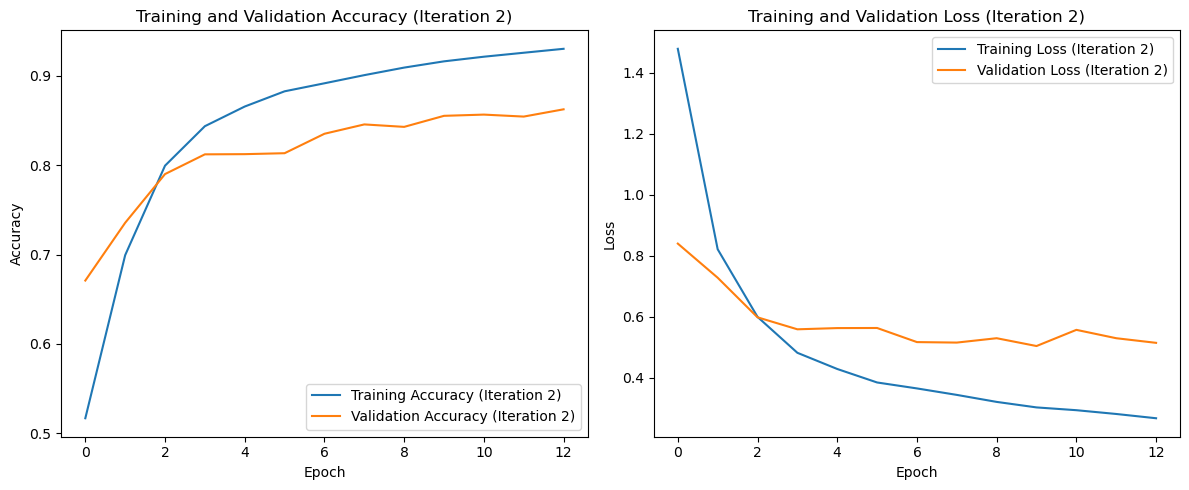

In [131]:
# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# Plot accuracy (second iteration)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy (Iteration 2)')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy (Iteration 2)')
plt.title('Training and Validation Accuracy (Iteration 2)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss (second iteration)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss (Iteration 2)')
plt.plot(history.history['val_loss'], label='Validation Loss (Iteration 2)')
plt.title('Training and Validation Loss (Iteration 2)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [132]:
# Predict labels for the test set (second iteration)
predicted_classes_2 = np.argmax(model.predict(X_test), axis=1)

# Convert one-hot encoded y_test to class labels (second iteration)
y_test_classes_2 = np.argmax(y_test, axis=1)

# Generate the classification report (second iteration)
print("Classification Report (Iteration 2):")
print(classification_report(y_test_classes_2, predicted_classes_2, target_names=['Negative', 'Neutral', 'Positive']))

# Generate the confusion matrix (second iteration)
print("Confusion Matrix (Iteration 2):")
print(confusion_matrix(y_test_classes_2, predicted_classes_2))

370/370 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step
Classification Report (Iteration 2):
              precision    recall  f1-score   support

    Negative       0.88      0.91      0.90      3910
     Neutral       0.87      0.82      0.84      4013
    Positive       0.81      0.83      0.82      3915

    accuracy                           0.85     11838
   macro avg       0.85      0.85      0.85     11838
weighted avg       0.85      0.85      0.85     11838

Confusion Matrix (Iteration 2):
[[3563  124  223]
 [ 200 3288  525]
 [ 281  375 3259]]


The decrease in train accuracy and train loss coupled with the slight decrease in test loss suggests that regularization has helped reduce overfitting, making the model more generalized.

## Hyperparameter Tuning

In [133]:
import keras_tuner as kt

# Model definition with tunable hyperparameters for LSTM units, dropout rate, and L2 regularization
def build_model(hp):
    model = Sequential([
        Embedding(input_dim=10000, output_dim=128),
        
        # Tuning the number of units in LSTM
        Bidirectional(LSTM(
            hp.Int('units_1', min_value=32, max_value=128, step=32),
            return_sequences=True,
            kernel_regularizer=regularizers.l2(hp.Float('l2_1', min_value=0.001, max_value=0.1, step=0.001))
        )),
        Dropout(hp.Float('dropout_1', min_value=0.2, max_value=0.6, step=0.2)),
        
        # Tuning the number of units in the second LSTM layer
        Bidirectional(LSTM(
            hp.Int('units_2', min_value=32, max_value=128, step=32),
            kernel_regularizer=regularizers.l2(hp.Float('l2_2', min_value=0.001, max_value=0.1, step=0.001))
        )),
        
        # Dense layer tuning
        Dense(hp.Int('dense_units', min_value=32, max_value=128, step=32), activation='relu'),
        Dropout(hp.Float('dropout_2', min_value=0.2, max_value=0.6, step=0.2)),
        
        Dense(3, activation='softmax')
    ])
    
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


### Round 1

In [134]:
# Round 1 Hyperparameter Tuning with a broader search space
def round_1_tune(X_train, y_train, X_val, y_val):
    tuner = kt.Hyperband(
        build_model,
        objective='val_accuracy',
        max_epochs=10,
        factor=3,
        directory='kt_tuner_dir',
        project_name='round_1_tune_model'
    )
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    # Start hyperparameter tuning for Round 1
    tuner.search(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=64, callbacks=[early_stopping])
    
    # Get the best model from the first round
    best_model_round_1 = tuner.get_best_models(num_models=1)[0]
    return best_model_round_1, tuner


### Round 2

In [135]:
# Round 2 Hyperparameter Tuning (Finer Search based on Round 1 results)
def round_2_tune(X_train, y_train, X_val, y_val, best_hyperparameters_round_1):
    tuner = kt.Hyperband(
        build_model,
        objective='val_accuracy',
        max_epochs=10,
        factor=3,
        directory='kt_tuner_dir',
        project_name='round_2_finer_tune_model'
    )
    
    # Modify the hyperparameter search space based on the best hyperparameters from Round 1
    tuner.oracle.hyperparameters.values['units_1'] = best_hyperparameters_round_1['units_1']
    tuner.oracle.hyperparameters.values['units_2'] = best_hyperparameters_round_1['units_2']
    tuner.oracle.hyperparameters.values['dropout_1'] = best_hyperparameters_round_1['dropout_1']
    tuner.oracle.hyperparameters.values['dropout_2'] = best_hyperparameters_round_1['dropout_2']
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    # Start hyperparameter tuning for Round 2
    tuner.search(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=64, callbacks=[early_stopping])
    
    # Get the best model from Round 2
    best_model_round_2 = tuner.get_best_models(num_models=1)[0]
    return best_model_round_2, tuner


In [136]:
# Main process
def main(X_train, y_train, X_val, y_val, X_test, y_test):
    # Round 1: Initial Tuning
    print("Starting Round 1: Hyperparameter Tuning")
    best_model_round_1, tuner_round_1 = round_1_tune(X_train, y_train, X_val, y_val)
    print("Round 1 tuning complete.")
    
    # Evaluate the best model from Round 1
    test_loss_round_1, test_accuracy_round_1 = best_model_round_1.evaluate(X_test, y_test)
    print(f"Test Loss (Round 1): {test_loss_round_1:.4f}")
    print(f"Test Accuracy (Round 1): {test_accuracy_round_1:.4f}")
    
    # Get best hyperparameters from Round 1
    best_hyperparameters_round_1 = tuner_round_1.oracle.get_best_trials(num_trials=1)[0].hyperparameters.values
    print("Best Hyperparameters from Round 1:", best_hyperparameters_round_1)
    
    # Round 2: Finer Tuning based on Round 1 results
    print("Starting Round 2: Finer Hyperparameter Tuning")
    best_model_round_2, tuner_round_2 = round_2_tune(X_train, y_train, X_val, y_val, best_hyperparameters_round_1)
    print("Round 2 tuning complete.")
    
    # Evaluate the best model from Round 2
    test_loss_round_2, test_accuracy_round_2 = best_model_round_2.evaluate(X_test, y_test)
    print(f"Test Loss (Round 2): {test_loss_round_2:.4f}")
    print(f"Test Accuracy (Round 2): {test_accuracy_round_2:.4f}")
    
    # Get best hyperparameters from Round 2
    best_hyperparameters_round_2 = tuner_round_2.oracle.get_best_trials(num_trials=1)[0].hyperparameters.values
    print("Best Hyperparameters from Round 2:", best_hyperparameters_round_2)

# Call the main function to start the process
# Ensure you have X_train, y_train, X_val, y_val, X_test, and y_test already prepared.
main(X_train, y_train, X_val, y_val, X_test, y_test)

Starting Round 1: Hyperparameter Tuning
Reloading Tuner from kt_tuner_dir\round_1_tune_model\tuner0.json


C:\Users\JISNA\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:719: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 36 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Round 1 tuning complete.
370/370 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - accuracy: 0.8710 - loss: 0.5287
Test Loss (Round 1): 0.5156
Test Accuracy (Round 1): 0.8762
Best Hyperparameters from Round 1: {'units_1': 96, 'l2_1': 0.04, 'dropout_1': 0.2, 'units_2': 96, 'l2_2': 0.005, 'dense_units': 128, 'dropout_2': 0.4, 'tuner/epochs': 10, 'tuner/initial_epoch': 4, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0012'}
Starting Round 2: Finer Hyperparameter Tuning
Reloading Tuner from kt_tuner_dir\round_2_finer_tune_model\tuner0.json
Round 2 tuning complete.
370/370 ━━━━━━━━━━━━━━━━━━━━ 38s 97ms/step - accuracy: 0.8646 - loss: 0.5127
Test Loss (Round 2): 0.5020
Test Accuracy (Round 2): 0.8678
Best Hyperparameters from Round 2: {'units_1': 96, 'l2_1': 0.044000000000000004, 'dropout_1': 0.2, 'units_2': 128, 'l2_2': 0.010000000000000002, 'dense_units': 64, 'dropout_2': 0.2, 'tuner/epochs': 10, 'tuner/initial_epoch': 0, 'tuner/bracket': 0, 'tuner/round': 0}


## Cross Validation

In [141]:
from sklearn.model_selection import KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras import regularizers

# Number of splits for K-Fold
K_FOLDS = 5  

# Updated main function with cross-validation
def cross_validate(X, y, X_test, y_test):
    kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
    fold_accuracies = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"\n=== Fold {fold + 1} / {K_FOLDS} ===")

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Round 1 Hyperparameter Tuning
        best_model_round_1, tuner_round_1 = round_1_tune(X_train, y_train, X_val, y_val)

        # Evaluate Round 1 Model
        test_loss_1, test_acc_1 = best_model_round_1.evaluate(X_test, y_test)
        print(f"Round 1 - Fold {fold + 1} Test Accuracy: {test_acc_1:.4f}")

        # Get best hyperparameters
        best_hyperparams_1 = tuner_round_1.oracle.get_best_trials(num_trials=1)[0].hyperparameters.values

        # Round 2 Hyperparameter Tuning
        best_model_round_2, tuner_round_2 = round_2_tune(X_train, y_train, X_val, y_val, best_hyperparams_1)

        # Evaluate Round 2 Model
        test_loss_2, test_acc_2 = best_model_round_2.evaluate(X_test, y_test)
        print(f"Round 2 - Fold {fold + 1} Test Accuracy: {test_acc_2:.4f}")

        fold_accuracies.append(test_acc_2)

    # Calculate and print average accuracy across all folds
    avg_accuracy = np.mean(fold_accuracies)
    print(f"\n=== Cross-Validation Completed ===")
    print(f"Average Test Accuracy over {K_FOLDS} folds: {avg_accuracy:.4f}")

# Call cross-validation function with prepared data
cross_validate(X_train, y_train, X_test, y_test)



=== Fold 1 / 5 ===
Reloading Tuner from kt_tuner_dir\round_1_tune_model\tuner0.json
370/370 ━━━━━━━━━━━━━━━━━━━━ 26s 64ms/step - accuracy: 0.8710 - loss: 0.5287
Round 1 - Fold 1 Test Accuracy: 0.8762
Reloading Tuner from kt_tuner_dir\round_2_finer_tune_model\tuner0.json
370/370 ━━━━━━━━━━━━━━━━━━━━ 38s 97ms/step - accuracy: 0.8646 - loss: 0.5127
Round 2 - Fold 1 Test Accuracy: 0.8678

=== Fold 2 / 5 ===
Reloading Tuner from kt_tuner_dir\round_1_tune_model\tuner0.json
370/370 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - accuracy: 0.8710 - loss: 0.5287
Round 1 - Fold 2 Test Accuracy: 0.8762
Reloading Tuner from kt_tuner_dir\round_2_finer_tune_model\tuner0.json
370/370 ━━━━━━━━━━━━━━━━━━━━ 37s 95ms/step - accuracy: 0.8646 - loss: 0.5127
Round 2 - Fold 2 Test Accuracy: 0.8678

=== Fold 3 / 5 ===
Reloading Tuner from kt_tuner_dir\round_1_tune_model\tuner0.json
370/370 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.8710 - loss: 0.5287
Round 1 - Fold 3 Test Accuracy: 0.8762
Reloading Tuner from kt

In [164]:
# Predict the labels for both training and test data
y_train_pred = np.argmax(model.predict(X_train), axis=1)
y_test_pred = np.argmax(model.predict(X_test), axis=1)

# Convert one-hot encoded y_train and y_test to class labels
y_train_true = np.argmax(y_train, axis=1)
y_test_true = np.argmax(y_test, axis=1)

# Print classification report for training and test data
print("Classification Report for Training Data:")
print(classification_report(y_train_true, y_train_pred))

print("Classification Report for Test Data:")
print(classification_report(y_test_true, y_test_pred))

1184/1184 ━━━━━━━━━━━━━━━━━━━━ 57s 48ms/step
370/370 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step
Classification Report for Training Data:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     12669
           1       0.95      0.88      0.91     12591
           2       0.89      0.95      0.92     12619

    accuracy                           0.93     37879
   macro avg       0.93      0.93      0.93     37879
weighted avg       0.93      0.93      0.93     37879

Classification Report for Test Data:
              precision    recall  f1-score   support

           0       0.88      0.91      0.90      3910
           1       0.87      0.82      0.84      4013
           2       0.81      0.83      0.82      3915

    accuracy                           0.85     11838
   macro avg       0.85      0.85      0.85     11838
weighted avg       0.85      0.85      0.85     11838



In [165]:
# Calculate and print accuracy for training and test data
train_accuracy = accuracy_score(y_train_true, y_train_pred)
test_accuracy = accuracy_score(y_test_true, y_test_pred)

print(f"Accuracy on Training Data: {train_accuracy:.2f}")
print(f"Accuracy on Test Data: {test_accuracy:.2f}")

Accuracy on Training Data: 0.93
Accuracy on Test Data: 0.85


1184/1184 ━━━━━━━━━━━━━━━━━━━━ 54s 46ms/step
370/370 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step


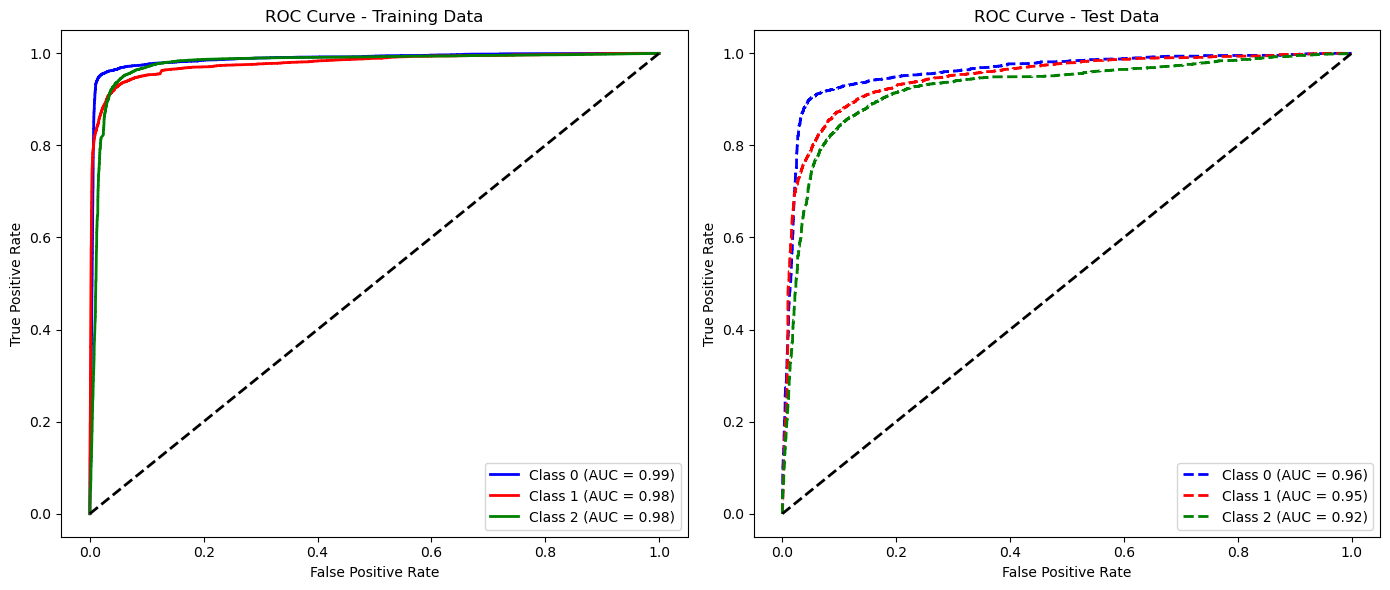

AUC for Class 0 on Training Data: 0.99
AUC for Class 0 on Test Data: 0.96
AUC for Class 1 on Training Data: 0.98
AUC for Class 1 on Test Data: 0.95
AUC for Class 2 on Training Data: 0.98
AUC for Class 2 on Test Data: 0.92


In [169]:
# Binarize the true labels for multi-class ROC
y_train_bin = label_binarize(y_train_true, classes=[0, 1, 2])
y_test_bin = label_binarize(y_test_true, classes=[0, 1, 2])
n_classes = y_train_bin.shape[1]

# Predict probabilities for each class on training and test data
y_train_proba = model.predict(X_train)
y_test_proba = model.predict(X_test)

# Compute ROC curve and AUC for each class on training and test data
fpr_train, tpr_train, roc_auc_train = {}, {}, {}
fpr_test, tpr_test, roc_auc_test = {}, {}, {}

for i in range(n_classes):
    # Train ROC curve
    fpr_train[i], tpr_train[i], _ = roc_curve(y_train_bin[:, i], y_train_proba[:, i])
    roc_auc_train[i] = auc(fpr_train[i], tpr_train[i])

    # Test ROC curve
    fpr_test[i], tpr_test[i], _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc_test[i] = auc(fpr_test[i], tpr_test[i])

# Create subplots for ROC curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot ROC curve for training data on the first subplot (ax1)
colors = ['blue', 'red', 'green']

for i, color in zip(range(n_classes), colors):
    ax1.plot(fpr_train[i], tpr_train[i], color=color, lw=2, label=f'Class {i} (AUC = {roc_auc_train[i]:.2f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line for random guessing
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve - Training Data')
ax1.legend(loc='lower right')

# Plot ROC curve for test data on the second subplot (ax2)
for i, color in zip(range(n_classes), colors):
    ax2.plot(fpr_test[i], tpr_test[i], color=color, lw=2, linestyle='--', label=f'Class {i} (AUC = {roc_auc_test[i]:.2f})')

ax2.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line for random guessing
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve - Test Data')
ax2.legend(loc='lower right')

# Display the plot
plt.tight_layout()
plt.show()

# Print AUC for each class on training and test data
for i in range(n_classes):
    print(f"AUC for Class {i} on Training Data: {roc_auc_train[i]:.2f}")
    print(f"AUC for Class {i} on Test Data: {roc_auc_test[i]:.2f}")


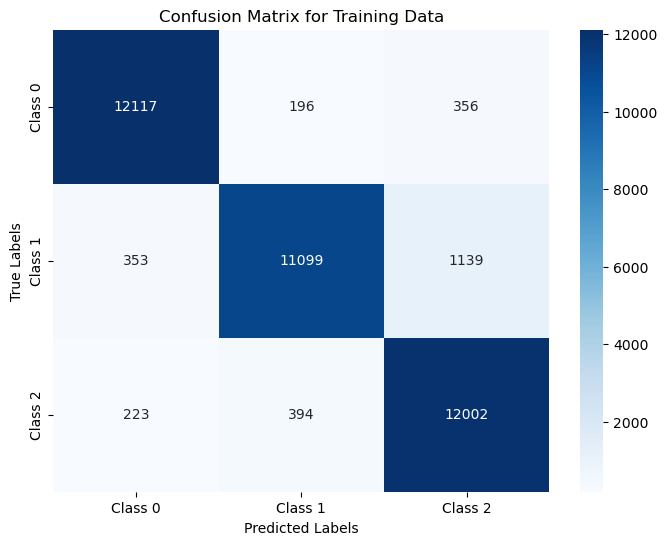

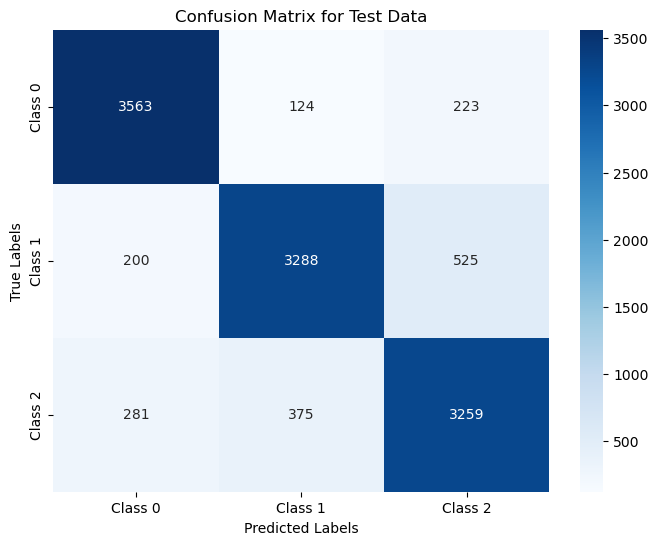

In [168]:
# Confusion Matrix for Training and Test Data
cm_train = confusion_matrix(y_train_true, y_train_pred)
cm_test = confusion_matrix(y_test_true, y_test_pred)

# Plot Confusion Matrix for Training Data
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=[f'Class {i}' for i in range(n_classes)], yticklabels=[f'Class {i}' for i in range(n_classes)])
plt.title('Confusion Matrix for Training Data')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Plot Confusion Matrix for Test Data
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=[f'Class {i}' for i in range(n_classes)], yticklabels=[f'Class {i}' for i in range(n_classes)])
plt.title('Confusion Matrix for Test Data')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## Interpretability

### LIME

In [157]:
from lime.lime_text import LimeTextExplainer
import numpy as np

# Initialize the explainer for text
explainer = LimeTextExplainer(class_names=['Negative', 'Neutral', 'Positive'])

# Define the function to predict probabilities for LIME
def predict_fn(texts):
    # Tokenize the texts and convert to padded sequences
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=100, padding='post')
    # Predict the probabilities using the trained model
    return model.predict(padded_sequences)

# Pick a sample tweet for interpretation
sample_tweet = df['Tweet'].iloc[42]  # You can change the index to choose any tweet

# Explain the prediction for the chosen sample tweet
explanation = explainer.explain_instance(sample_tweet, predict_fn, num_features=10)

# Visualize the explanation
explanation.show_in_notebook(text=True)

# Alternatively, you can save the explanation as an HTML file for further inspection
explanation.save_to_file("lime_explanation.html")


157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step


In [174]:
from IPython.display import display, HTML  # Fixed import

# Extract LIME explanation as a dictionary
lime_exp = explanation.as_list()

# Convert LIME explanation into a DataFrame
df_lime = pd.DataFrame(lime_exp, columns=['Word', 'Impact'])

# Identify top words contributing to negative and positive predictions
top_negative_words = df_lime[df_lime['Impact'] < 0].sort_values(by='Impact').head(3)
top_positive_words = df_lime[df_lime['Impact'] > 0].sort_values(by='Impact', ascending=False).head(3)

# Generate report summary
report_html = f"""
<h2>LIME Explanation Report</h2>
<h3>Sample Tweet:</h3>
<p>{sample_tweet}</p>

<h3>Prediction Probabilities:</h3>
<ul>
    <li><b>Negative:</b> {explanation.predict_proba[0]:.2f}</li>
    <li><b>Neutral:</b> {explanation.predict_proba[1]:.2f}</li>
    <li><b>Positive:</b> {explanation.predict_proba[2]:.2f}</li>
</ul>

<h3>Key Insights:</h3>
<ul>
    <li><b>Strongest Negative Contributors:</b> {', '.join(top_negative_words['Word'].tolist())}</li>
    <li><b>Strongest Positive Contributors:</b> {', '.join(top_positive_words['Word'].tolist())}</li>
</ul>
"""

# Display the report in Jupyter Notebook
display(HTML(report_html))

# Save the report as an HTML file
with open("lime_report.html", "w", encoding="utf-8") as f:
    f.write(report_html)

print("LIME report saved as 'lime_report.html'")


LIME report saved as 'lime_report.html'
